# End-to-end BPAM-4 with a trainable TX lookup table

Derived from `bpam_surrogate.ipynb`, with the same physical chain and RX architecture.
The TX neural mapping is replaced by an **Embedding(1024, 2)**:
10 input bits (5 symbols) address two drive values in volts, before pulse shaping and DAC.
The RX remains a fully connected 12-64-128-32-2 network.

1. Fit or load the hybrid digital surrogate (simulator I/O, not laboratory data).
2. Train or load the original NN-TX/RX pair through that frozen digital surrogate.
3. Enumerate the NN-TX mapping, then jointly train the LUT entries and RX weights.
   The digital surrogate stays frozen. Adam, the original loss and fixed training SNR
   are retained; after each update, entries are clipped to the original voltage range.

Compatible models from `results/bpam_surrogate/` may be read for initialization.
All new checkpoints and outputs are written only to `results/bpam_lut/`.
`FORCE_RETRAIN=True` refits the digital surrogate, retrains the initializer and then
trains LUT + RX, without overwriting the source notebook's checkpoints.
`FORCE_RETRAIN=False` loads compatible stages and trains missing ones.

The default **5000 LUT steps** reproduce the pilot budget, not a convergence claim.
This is NN-initialized LUT fine-tuning, not training a random LUT from scratch.
The current implementation does not support differential precoding.
OSNR = Eb/N0 + 2.05 dB.


## 1. Setup and knobs

In [9]:
# Resolve paths independently of the notebook's working directory.
from pathlib import Path
import os
import sys
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "functions" / "config.py").is_file())
sys.path.insert(0, str(PROJECT_ROOT / "functions"))
os.chdir(PROJECT_ROOT)

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
import json
import hashlib
from pathlib import Path
sys.path.insert(0, "functions")

%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import matplotlib.pyplot as plt

from scenarios import asfand_complex, OSNR_OFFSET_DB, TRAIN_EBN0_DB, TRAIN_STEPS
from train import train, evaluate

%matplotlib inline
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# ---------------- knobs ----------------
ADC_BITS   = [8, 6, 5]        # the family of the paper figure
PRECODE    = False            # this LUT implementation supports raw input bits only
TX_PULSE   = None             # None = scenario default (freq-rect 20 GHz), the PUBLISHED curve.
NRZ_RECT   = 1.0              # "nrz" + NRZ_RECT = NRZ pulse cascaded with the 20 GHz rect.
                              # h(T/2): NRZ 0.61 -> cascade 0.45 -> freq-rect alone 0.00. The bare
                              # freq-rect nulls the T/2 cross-term that carries the differential
                              # sign, so a bipolar constellation is undecodable with it -- but this
                              # E2E is UNIPOLAR anyway and the freq-rect serves it better: measured
                              # 1.80e-4 (freq-rect) vs 3.39e-4 (NRZ cascade) at OSNR 17, N_ADC=6.
                              # The NRZ cascade belongs to bpam_warmstart, where the signal IS bipolar.
SEED       = 0
NUM_STEPS  = TRAIN_STEPS      # NN-TX/RX initialization: 100k steps
LUT_STEPS  = 5_000            # additional joint LUT + RX steps (pilot budget)
LUT_SEED   = 20260916         # same fine-tuning seed as the matched-budget pilot
FORCE_RETRAIN = False

OSNR_GRID = list(range(11, 21))
EBN0_FOR_OSNR = [o - OSNR_OFFSET_DB for o in OSNR_GRID]

def num_symbols(ebn0_db):
    return 4_000_000 if ebn0_db <= 14.0 else 16_000_000

print(asfand_complex(adc_bits=6, precode=PRECODE, rx="asfand").summary())

from simulated_surrogate import prepare_digital_surrogate, frozen_channel, file_digest, signature
from tx_lut import LookupTransmitter, TrainableLookupTransmitter
from lut_training import train_lut

SOURCE_WORK = Path("results") / "bpam_surrogate"  # read-only initialization cache
WORK = Path("results") / "bpam_lut"
WORK.mkdir(parents=True, exist_ok=True)

def make_config(adc_bits):
    cfg = asfand_complex(adc_bits=adc_bits, precode=PRECODE, rx="asfand")
    if TX_PULSE is not None:
        cfg.tx_filter = TX_PULSE
        cfg.nrz_rect_cutoff_ratio = NRZ_RECT
        cfg._compute_derived()
        cfg.set_modulation_format("bpam-4")
    return cfg

if PRECODE:
    raise ValueError("This notebook requires PRECODE=False.")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
device: cuda
symbol rate          : 20 GBaud
bit rate             : 40 Gb/s  (bipolar PAM-4/DD (differential sign, 2 rx sps))
sim sample rate      : 40 GHz  (2 sps, Nyquist 20 GHz)
rx sample rate       : 40 GHz  (2 sps)
photodiode bandwidth : 25 GHz  (representable: False)
modulator            : mzm  (MZM 30 GHz, 1 segments)
pulse shape          : freq-rect 20 GHz (brickwall)
equalizer            : DPD (TX) + FFE (RX), trained jointly
wavelength band      : cband  (1550 nm, beta2 -21.7 ps^2/km, L 10.238 km, beta2*L -222.2 ps^2)
noise regime         : ase
optical filter       : wss, Bo 37 GHz


## 2. Fit/load the digital surrogate and the NN initializer; train/load LUT + RX

The fitted digital surrogate is shared across ADC resolutions; ADC quantization is
outside its drive-to-photocurrent boundary. Its held-out waveform and gradient checks
must pass before either joint-training stage.

Cache keys include configuration, source code, training settings and upstream checkpoint
digests. Only the final LUT/RX pair is used for the BER and eye cells below.
Lookup address order is bit-stream-major, MSB first:
`[b0[k-2], ..., b0[k+2], b1[k-2], ..., b1[k+2]]`.
Sequence boundaries use the same zero padding as the NN-TX.


In [10]:
from transmitter import Transmitter
from receiver import Receiver

# Prefer an existing local fit; otherwise reuse the source notebook's compatible
# fit read-only. FORCE_RETRAIN always writes a new fit in this notebook's folder.
digital_key, _ = signature(make_config(6))
local_directory = WORK / "digital_surrogate"
shared_directory = SOURCE_WORK / "surrogate"  # legacy on-disk cache name
local_exists = (local_directory / digital_key[:16] / "validation.json").exists()
shared_exists = (shared_directory / digital_key[:16] / "validation.json").exists()
fit_directory = (shared_directory if shared_exists and not local_exists
                 and not FORCE_RETRAIN else local_directory)
digital_surrogate_info = prepare_digital_surrogate(
    make_config(6), fit_directory, device, force_retrain=FORCE_RETRAIN)
print("Digital surrogate test NMSE:", digital_surrogate_info["report"]["test_nmse"])

def save_checkpoint(path, payload):
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(".tmp")
    torch.save(payload, temporary)
    temporary.replace(path)

def load_initializer(adc_bits, force_retrain=False):
    cfg = make_config(adc_bits)
    cfg.channel_source = "surrogate"  # legacy channel-factory API
    cfg.surrogate_checkpoint = digital_surrogate_info["checkpoint"]
    # Keep the source notebook's metadata schema for exact cache compatibility.
    metadata = {
        "config": vars(cfg), "surrogate_sha256": digital_surrogate_info["sha256"],
        "seed": SEED, "steps": NUM_STEPS, "train_ebn0_db": TRAIN_EBN0_DB,
        "source_sha256": {name: file_digest(Path("functions") / f"{name}.py")
                          for name in ("train", "transmitter", "receiver", "utils", "pulse_shaping")},
    }
    key = hashlib.sha256(json.dumps(metadata, sort_keys=True).encode()).hexdigest()[:16]
    name = f"e2e_adc{adc_bits}_{key}.pt"
    local = WORK / "initializers" / name
    candidates = (local, SOURCE_WORK / "checkpoints" / name)
    existing = next((p for p in candidates if p.exists()), None)
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    if existing is not None and not force_retrain:
        state = torch.load(existing, map_location=device, weights_only=True)
        if state["metadata"] != metadata:
            raise RuntimeError("Incompatible initializer checkpoint.")
        tx, rx = Transmitter(cfg).to(device), Receiver(cfg).to(device)
        ch = frozen_channel(cfg, cfg.surrogate_checkpoint, device)
        tx.load_state_dict(state["tx"])
        rx.load_state_dict(state["rx"])
        path = existing
        print(f"Loaded NN initializer: {path}")
    else:
        print(f"Training NN initializer N_ADC={adc_bits}: {NUM_STEPS} steps")
        tx, ch, rx = train(cfg, device, num_steps=NUM_STEPS,
                           ebn0_range=(TRAIN_EBN0_DB, TRAIN_EBN0_DB))
        path = local
        save_checkpoint(path, {"tx": tx.state_dict(), "rx": rx.state_dict(), "metadata": metadata})
    return tx.eval(), ch.eval(), rx.eval(), cfg, path

def load_or_train(adc_bits, force_retrain=False):
    nn_tx, ch, rx, cfg, initializer_path = load_initializer(adc_bits, force_retrain)
    fixed_lut = LookupTransmitter.from_transmitter(nn_tx)
    tx = TrainableLookupTransmitter.from_lookup(fixed_lut).to(device)
    metadata = {
        "config": vars(cfg), "initializer_sha256": file_digest(initializer_path),
        "digital_surrogate_sha256": digital_surrogate_info["sha256"],
        "seed": LUT_SEED, "steps": LUT_STEPS, "train_ebn0_db": TRAIN_EBN0_DB,
        "learning_rate": cfg.learning_rate, "voltage_projection": [tx.drive_min, tx.drive_max],
        "address_order": "bit-stream-major, MSB-first",
        "source_sha256": {name: file_digest(Path("functions") / f"{name}.py")
                          for name in ("tx_lut", "lut_training", "train", "transmitter",
                                       "receiver", "channel", "utils", "pulse_shaping")},
    }
    key = hashlib.sha256(json.dumps(metadata, sort_keys=True).encode()).hexdigest()[:16]
    path = WORK / "checkpoints" / f"lut_adc{adc_bits}_{key}.pt"
    if path.exists() and not force_retrain:
        state = torch.load(path, map_location=device, weights_only=True)
        if state["metadata"] != metadata:
            raise RuntimeError("Incompatible LUT/RX checkpoint.")
        tx.load_state_dict(state["tx"])
        rx.load_state_dict(state["rx"])
        print(f"Loaded LUT + RX: {path}")
    else:
        # Independent RNG for a bounded initialization check.
        generator = torch.Generator(device=device).manual_seed(918)
        bits = torch.randint(0, 2, (cfg.bits_per_symbol, 8192),
                             generator=generator, device=device)
        with torch.no_grad():
            torch.testing.assert_close(tx.symbol_drive_levels(bits),
                                       nn_tx.symbol_drive_levels(bits), atol=1e-5, rtol=0)
            if not torch.equal(tx(bits), nn_tx(bits)):
                raise RuntimeError("Initialization check failed after DAC; inspect before training.")
        print(f"Training LUT + RX N_ADC={adc_bits}: {LUT_STEPS} steps")
        history = train_lut(tx, ch, rx, cfg, LUT_STEPS, TRAIN_EBN0_DB, LUT_SEED)
        save_checkpoint(path, {"tx": tx.state_dict(), "rx": rx.state_dict(),
                               "metadata": metadata, "history": history})
    assert all(not p.requires_grad and p.grad is None for p in ch.parameters())
    tx.eval()
    rx.eval()
    # Export the learned voltage entries separately from the full RX checkpoint.
    table_path = WORK / "tables" / f"lut_adc{adc_bits}_{key}.txt"
    table_path.parent.mkdir(parents=True, exist_ok=True)
    values = tx.embedding.weight.detach().cpu().numpy()
    np.savetxt(table_path, values, fmt="%.9g",
               header="Learned LUT: two drive values [V] per row, before pulse shaping and DAC.\n"
                      "Row index 0..1023: MSB-first [b0[k-2]..b0[k+2], b1[k-2]..b1[k+2]].")
    print("LUT shape:", values.shape)
    return tx, ch, rx, cfg

nets = {}
for adc in ADC_BITS:
    nets[adc] = load_or_train(adc, force_retrain=FORCE_RETRAIN)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
print("Ready:", list(nets))


Loaded validated digital surrogate: results\bpam_lut\digital_surrogate\1a75b1d37b8e9394\surrogate.pt
Digital surrogate test NMSE: 1.5954971099415673e-12
Loaded NN initializer: results\bpam_lut\initializers\e2e_adc8_0503dcd312de6433.pt
Loaded LUT + RX: results\bpam_lut\checkpoints\lut_adc8_8e550a0954f63234.pt
LUT shape: (1024, 2)
Loaded NN initializer: results\bpam_lut\initializers\e2e_adc6_07efdad980744731.pt
Loaded LUT + RX: results\bpam_lut\checkpoints\lut_adc6_03d5a5b95443d051.pt
LUT shape: (1024, 2)
Loaded NN initializer: results\bpam_lut\initializers\e2e_adc5_5eeda33edbc9127e.pt
Loaded LUT + RX: results\bpam_lut\checkpoints\lut_adc5_60d8e0a4e823c000.pt
LUT shape: (1024, 2)
Ready: [8, 6, 5]


## 3. Measure BER versus OSNR


In [11]:
results = {"osnr": {}}

for adc, (tx, ch, rx, cfg) in nets.items():
    results["osnr"][adc] = [evaluate(tx, ch, rx, cfg, [e], num_symbols(e), device)[0]
                            for e in EBN0_FOR_OSNR]
    torch.cuda.empty_cache()
    print(f"N_ADC={adc}  done")

print("\nOSNR [dB]  " + " ".join(f"{o:>9d}" for o in OSNR_GRID))
for adc in ADC_BITS:
    print(f"N_ADC={adc}   " + " ".join(f"{b:9.2e}" for b in results["osnr"][adc]))


Eb/N0   8.9 dB   BER 3.855e-02   (shift 0)
Eb/N0   9.9 dB   BER 2.149e-02   (shift 0)
Eb/N0  10.9 dB   BER 1.052e-02   (shift 0)
Eb/N0  11.9 dB   BER 4.319e-03   (shift 0)
Eb/N0  12.9 dB   BER 1.565e-03   (shift 0)
Eb/N0  13.9 dB   BER 4.553e-04   (shift 0)
Eb/N0  14.9 dB   BER 1.086e-04   (shift 0)
Eb/N0  15.9 dB   BER 2.191e-05   (shift 0)
Eb/N0  16.9 dB   BER 3.219e-06   (shift 0)
Eb/N0  17.9 dB   BER 2.813e-07   (shift 0)
N_ADC=8  done
Eb/N0   8.9 dB   BER 4.016e-02   (shift 0)
Eb/N0   9.9 dB   BER 2.227e-02   (shift 0)
Eb/N0  10.9 dB   BER 1.104e-02   (shift 0)
Eb/N0  11.9 dB   BER 4.764e-03   (shift 0)
Eb/N0  12.9 dB   BER 1.716e-03   (shift 0)
Eb/N0  13.9 dB   BER 5.034e-04   (shift 0)
Eb/N0  14.9 dB   BER 1.301e-04   (shift 0)
Eb/N0  15.9 dB   BER 2.847e-05   (shift 0)
Eb/N0  16.9 dB   BER 5.313e-06   (shift 0)
Eb/N0  17.9 dB   BER 1.031e-06   (shift 0)
N_ADC=6  done
Eb/N0   8.9 dB   BER 4.388e-02   (shift 0)
Eb/N0   9.9 dB   BER 2.552e-02   (shift 0)
Eb/N0  10.9 dB   BER 1.318

## 4. Load the historical BPAM + adaptive-equalizer reference

This is the same MATLAB reference file used by `bpam_complex.ipynb`, not a new
digital surrogate-transfer control. It is read only and is not regenerated here.


In [12]:
REF = os.path.join("results", "paper", "bpam_ae_reference_osnrgrid.txt")
baseline = {}
for line in open(REF):
    if line.startswith("#") or not line.strip():
        continue
    p = line.split()
    nb = int(p[0])
    baseline.setdefault(nb, {"ebn0": [], "osnr": [], "ber": []})
    baseline[nb]["ebn0"].append(float(p[2]))
    baseline[nb]["osnr"].append(float(p[3]))
    baseline[nb]["ber"].append(float(p[4]))
print("baseline loaded for N_ADC:", sorted(baseline))


baseline loaded for N_ADC: [5, 6, 8]


## 5. Column files (the format shared with the co-authors)


In [13]:
OUT = str(WORK)
os.makedirs(OUT, exist_ok=True)

HEADER = (
    "# End-to-end autoencoder trained and tested through a fitted hybrid digital surrogate, C-band 10.238 km, MZM ER 30 dB, TX 20 GHz rect, WSS optical filter,\n"
    "# RX 10 GHz Gaussian, N_DAC = 6, 2 samples/symbol. RX-DSP = fully connected 64-128-32 with\n"
    "# sigmoid output, context window 6 symbols (12 samples); TX-DSP = trainable LUT (1024 rows, 2 voltages per row).\n"
    "# OSNR = Eb/N0 + 2.05 dB (signal 1 pol, ASE 2 pol, Bref 12.5 GHz).\n"
    "\n"
    f"# NN initialization: {NUM_STEPS} steps; joint LUT + RX: {LUT_STEPS} steps; frozen digital surrogate.\n"
    "# columns:\n")

def save(axis, grid, axis_name, fname):
    heads = [f"{axis_name}[dB]"] + [f"E2E_adc{nb}" for nb in ADC_BITS] + \
            [f"BPAM_AE_adc{nb}" for nb in ADC_BITS]
    cols = [results[axis][nb] for nb in ADC_BITS] + [[dict(zip(baseline[nb]["osnr"], baseline[nb]["ber"]))[float(x)] for x in grid] for nb in ADC_BITS]
    with open(os.path.join(OUT, fname), "w") as f:
        f.write(HEADER)
        f.write("# " + "  ".join(f"{h:>16s}" for h in heads)[2:] + "\n\n")
        for i, x in enumerate(grid):
            f.write(f"{x:8.2f}  " + "  ".join(f"{c[i]:16.4e}" for c in cols) + "\n")
    print("written", os.path.join(OUT, fname))

save("osnr", OSNR_GRID, "OSNR", "bpam_lut.txt")


written results\bpam_lut\bpam_lut.txt


## 6. Figures

Solid: end-to-end. Dashed: BPAM + adaptive equalizer, same `N_ADC` (same color).


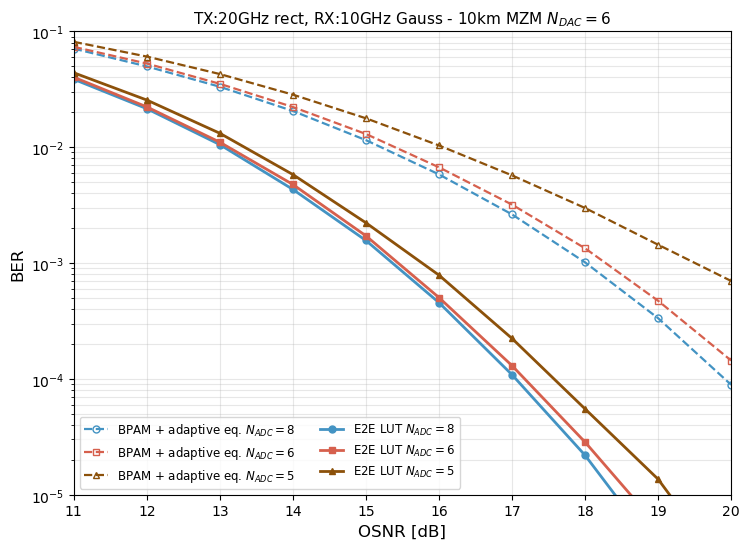

In [14]:
STYLE = {8: ("o", "#4393c3"), 6: ("s", "#d6604d"), 5: ("^", "#8c510a")}

def figure(axis, grid, xlabel, bkey, fname):
    fig, ax = plt.subplots(figsize=(7.6, 5.6))
    for nb in ADC_BITS:
        mk, c = STYLE[nb]
        pts = [(x, y) for x, y in zip(baseline[nb][bkey], baseline[nb]["ber"]) if y > 0]
        ax.semilogy([p[0] for p in pts], [p[1] for p in pts], "--" + mk, color=c, lw=1.6,
                    ms=5, mfc="none", label=f"BPAM + adaptive eq. $N_{{ADC}}={nb}$")
    for nb in ADC_BITS:
        mk, c = STYLE[nb]
        ax.semilogy(grid, np.maximum(results[axis][nb], 1e-7), "-" + mk, color=c, lw=2,
                    ms=5, label=f"E2E LUT $N_{{ADC}}={nb}$")
    ax.set_xlim(min(grid), max(grid)); ax.set_ylim(1e-5, 1e-1); ax.set_xticks(grid)
    ax.set_xlabel(xlabel, fontsize=12); ax.set_ylabel("BER", fontsize=12)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8.5, loc="lower left", ncol=2)
    ax.set_title("TX:20GHz rect, RX:10GHz Gauss - 10km MZM $N_{DAC}=6$", fontsize=11)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT, fname + ".pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(OUT, fname + ".png"), bbox_inches="tight", dpi=150)
    plt.show()

figure("osnr", OSNR_GRID, "OSNR [dB]", "osnr", "bpam_lut")


## 6b. Noiseless photocurrent eye through the fitted digital surrogate

The waveform is taken after the digital surrogate photodetector response and the RX
Gaussian filter, before the ADC. No matched filter is applied. Interpolation
is for display only; it does not turn the 2-sps simulation into a high-rate simulation.


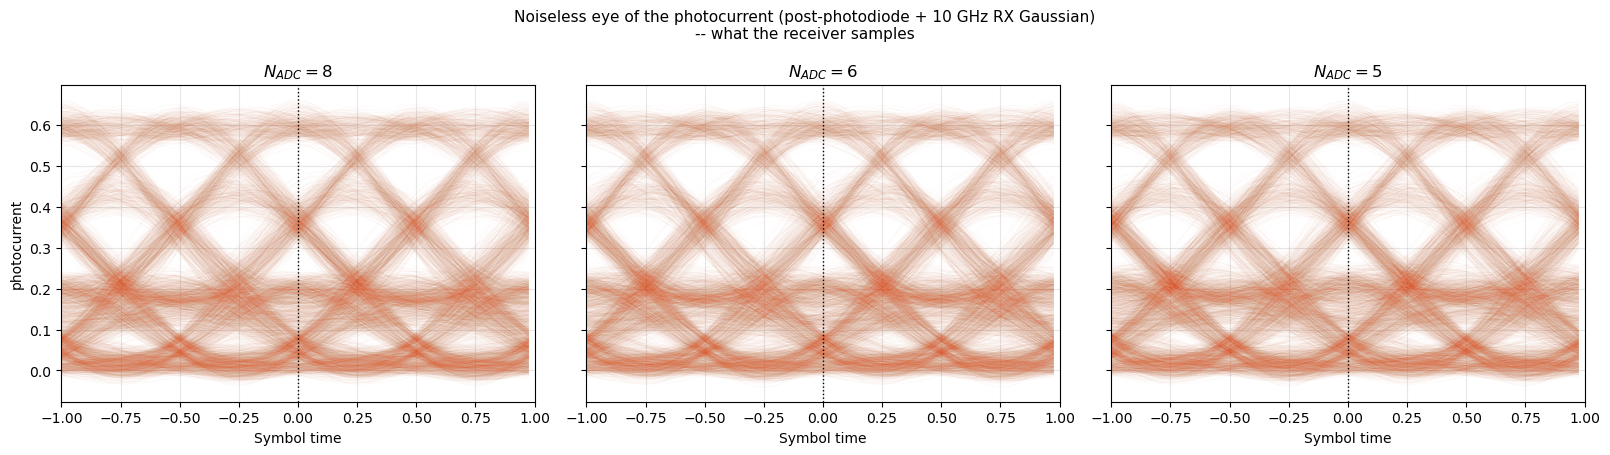

In [15]:
import torch.nn.functional as F
from scipy.signal import resample_poly
from train import random_bits
from transmitter import bits_to_symbols
from utils import decision_phase_by_separation

def draw_eye(ax, signal, samples_per_symbol, phase, title, fine_sps=40, skip=100, num_symbols=4000):
    fine = resample_poly(signal[:(skip + num_symbols + 8) * samples_per_symbol],
                         fine_sps, samples_per_symbol)
    offset = int(round(phase * fine_sps / samples_per_symbol))
    centers = (skip + np.arange(num_symbols)) * fine_sps + offset
    keep = (centers - fine_sps >= 0) & (centers + fine_sps < len(fine))
    centers = centers[keep]
    window = np.arange(-fine_sps, fine_sps)[:, None] + centers[None, :]
    ax.plot(np.arange(-fine_sps, fine_sps) / fine_sps, fine[window],
            color=(0.85, 0.33, 0.10, 0.03), linewidth=0.4)
    ax.axvline(0, color="k", linestyle=":", linewidth=1)
    ax.set_xlim(-1, 1)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Symbol time")
    ax.set_title(title)

fig, axes = plt.subplots(1, len(nets), figsize=(5.4 * len(nets), 4.6), sharey=True)
axes = np.atleast_1d(axes)
for ax, (adc, (tx, ch, rx, cfg)) in zip(axes, nets.items()):
    sps = cfg.samples_per_symbol_sim
    torch.manual_seed(7)
    with torch.no_grad():
        bits = random_bits(cfg.bits_per_symbol, 6000, device)
        symbols = bits_to_symbols(bits, cfg.bits_per_symbol).cpu().numpy()
        p = ch(tx(bits), ase_ebn0_db=None)                    # noiseless photocurrent (post-photodiode)
        if rx.rx_gauss is not None:                           # 10 GHz RX Gaussian (the RX electrical filter)
            p = F.conv1d(p.view(1, 1, -1), rx.rx_gauss, padding=rx.rx_gauss.shape[-1] // 2).view(-1)
        photocurrent = p.cpu().numpy()
    phase, _ = decision_phase_by_separation(photocurrent, sps, symbols, skip=100)
    title = "ideal ADC" if adc is None else f"$N_{{ADC}}={adc}$"
    draw_eye(ax, photocurrent, sps, phase, title)
axes[0].set_ylabel("photocurrent")
fig.suptitle("Noiseless eye of the photocurrent (post-photodiode + 10 GHz RX Gaussian)\n"
             "-- what the receiver samples", fontsize=11)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "bpam_lut_eyes.png"), dpi=150, bbox_inches="tight")
plt.show()


## 7. Horizontal gain vs the reference, at equal ADC resolution


In [16]:
def crossing(x, y, target):
    x = np.asarray(x, float)
    ly = np.log10(np.maximum(np.asarray(y, float), 1e-12))
    lt = np.log10(target)
    for i in range(len(x) - 1):
        if (ly[i] - lt) * (ly[i + 1] - lt) <= 0:
            return x[i] + (x[i + 1] - x[i]) * (lt - ly[i]) / (ly[i + 1] - ly[i])
    return np.nan

for target in (1e-2, 1e-3):
    print(f"\nBER = {target:.0e}   (OSNR axis)")
    for nb in ADC_BITS:
        bx = [x for x, y in zip(baseline[nb]["osnr"], baseline[nb]["ber"]) if y > 0]
        by = [y for y in baseline[nb]["ber"] if y > 0]
        gb = crossing(bx, by, target)
        ge = crossing(OSNR_GRID, results["osnr"][nb], target)
        print(f"  N_ADC={nb}:  baseline @ {gb:5.2f} dB   E2E @ {ge:5.2f} dB"
              f"   ->  gain {gb - ge:+.2f} dB")



BER = 1e-02   (OSNR axis)
  N_ADC=8:  baseline @ 15.21 dB   E2E @ 13.06 dB   ->  gain +2.15 dB
  N_ADC=6:  baseline @ 15.40 dB   E2E @ 13.12 dB   ->  gain +2.28 dB
  N_ADC=5:  baseline @ 16.06 dB   E2E @ 13.34 dB   ->  gain +2.72 dB

BER = 1e-03   (OSNR axis)
  N_ADC=8:  baseline @ 18.01 dB   E2E @ 15.36 dB   ->  gain +2.65 dB
  N_ADC=6:  baseline @ 18.28 dB   E2E @ 15.44 dB   ->  gain +2.84 dB
  N_ADC=5:  baseline @ 19.51 dB   E2E @ 15.77 dB   ->  gain +3.74 dB
